# AgroBench: Vision-Language Model Benchmark in Agriculture

**Authors**: Risa Shinoda, Nakamasa Inoue, Hirokatsu Kataoka, Masaki Onishi, Yoshitaka Ushiku (ICCV'25)

**Dataset**: [AgroBench on Hugging Face](https://huggingface.co/datasets/risashinoda/AgroBench)

This notebook allows you to run the AgroBench benchmark on Google Colab with different Vision-Language Models.

## 1. Setup Environment

First, let's install all required dependencies.

In [1]:
!pip install -q python-dotenv>=1.0.1
!pip install -q datasets>=3.1.0
!pip install -q tqdm>=4.66.6
!pip install -q pyyaml>=6.0.2
!pip install -q pillow>=10.4.0
!pip install -q google-genai>=0.1.0

# specific versions to avoid conflicts
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

!pip install -q transformers>=4.43.0 accelerate

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


## 2. Set API Keys

Configure your API keys for different models. You only need to set the keys for the models you plan to use.

In [3]:
import os

from google.colab import userdata
userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] =userdata.get('HF_TOKEN')

print("✅ API keys configured!")

✅ API keys configured!


In [4]:
import json
import os
import re
import io
from collections import defaultdict
from typing import List, Dict, Any, Optional, Iterator
from dataclasses import dataclass

import torch
from PIL import Image
from datasets import load_dataset
from tqdm.auto import tqdm

print("✅ Modules imported successfully!")

✅ Modules imported successfully!


## 4. Define Helper Functions

These functions handle dataset loading, prompting, and evaluation.

In [5]:
# Dataset utilities
def load_agrobench(name: str, split: str, max_items: Optional[int] = None) -> Iterator[Dict[str, Any]]:
    """Load AgroBench dataset from Hugging Face."""
    ds = load_dataset(name, split=split)
    if max_items is not None:
        ds = ds.select(range(min(max_items, len(ds))))
    for row in ds:
        yield row

# Prompt utilities
LETTER = ["A", "B", "C", "D", "E"]

def mcq_prompt(question: str, options: List[str]) -> str:
    """Build a multiple-choice prompt string for the model."""
    lines = [question.strip()]
    for i, opt in enumerate(options):
        lines.append(f"{LETTER[i]}. {opt}")
    lines.append("Answer with the option's letter from the given choices directly.")
    return "\n".join(lines)

def letter_from_text(choice: str, options: List[str]) -> Optional[str]:
    """Extract a single letter (A–E) from the model's response."""
    letters = ["A", "B", "C", "D", "E"]
    if not choice:
        return None

    text = choice.strip().upper()

    # Normalize patterns like "A.", "A:", "A -", etc.
    match = re.match(r"^\s*([A-E])[\.:\-\s]*", text)
    if match:
        return match.group(1)

    # Exact single-letter case
    if text in letters[:len(options)]:
        return text

    # Match option text itself
    for i, opt in enumerate(options):
        if opt.lower() in text.lower():
            return letters[i]

    return None

# IO utilities
def append_jsonl(path: str, obj: dict) -> None:
    """Append a JSON object to a JSONL file."""
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")

# Scoring utilities
def compute_accuracy(rows: List[Dict[str, Any]]) -> Dict[str, Any]:
    """Compute overall and per-category accuracy."""
    total = 0
    correct = 0
    by_cat_total = defaultdict(int)
    by_cat_correct = defaultdict(int)
    by_source_total = defaultdict(int)
    by_source_correct = defaultdict(int)

    for r in rows:
        total += 1
        cat = r.get("category", "unknown")
        source = r.get("source", "unknown")
        by_cat_total[cat] += 1
        by_source_total[source] += 1

        if r.get("pred_letter") == r.get("gold_letter"):
            correct += 1
            by_cat_correct[cat] += 1
            by_source_correct[source] += 1

    overall = correct / total if total else 0.0
    per_cat = {
        c: (by_cat_correct[c] / by_cat_total[c] if by_cat_total[c] else 0.0)
        for c in by_cat_total
    }
    per_source = {
        s: (by_source_correct[s] / by_source_total[s] if by_source_total[s] else 0.0)
        for s in by_source_total
    }

    return {
        "overall": overall,
        "per_category": per_cat,
        "per_source": per_source,
        "n": total
    }

print("✅ Helper functions defined!")

✅ Helper functions defined!


## 5. Define Model Runners

Implement runners for different Vision-Language Models.

In [6]:
# Base runner class
class BaseRunner:
    def predict(self, question: str, options: List[str], pil_image: Image.Image) -> str:
        raise NotImplementedError

print("✅ Base runner defined!")

✅ Base runner defined!


In [7]:
from transformers import AutoModelForCausalLM, AutoProcessor

class Phi3VisionRunner(BaseRunner):
    """Runner for Microsoft Phi-3 Vision model."""

    def __init__(
        self,
        model: str = "microsoft/Phi-3-vision-128k-instruct",
        max_new_tokens: int = 128,
        temperature: float = 0.0,
    ):
        # Choose device (GPU if available, otherwise CPU)
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.torch_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

        print(f"Loading Phi-3 Vision model on {self.device}...")

        # Load the processor (handles images + text)
        self.processor = AutoProcessor.from_pretrained(
            model,
            trust_remote_code=True
        )

        # Load the model with specific settings to avoid cache issues
        self.model = AutoModelForCausalLM.from_pretrained(
            model,
            torch_dtype=self.torch_dtype,
            trust_remote_code=True,
            _attn_implementation="eager",
            low_cpu_mem_usage=True,
        ).to(self.device).eval()

        self.max_new_tokens = max_new_tokens
        self.temperature = temperature

        print(f"✅ Phi-3 Vision model loaded successfully!")

    def predict(self, question: str, options: List[str], pil_image: Image.Image) -> str:
        """Perform inference using Phi-3 Vision model."""
        try:
            # Build the text prompt
            prompt = mcq_prompt(question, options)

            # Format for Phi-3 Vision (uses special tokens)
            messages = [
                {
                    "role": "user",
                    "content": f"<|image_1|>\n{prompt}"
                }
            ]

            # Apply chat template
            text_prompt = self.processor.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

            # Process image + text together
            inputs = self.processor(
                text_prompt,
                [pil_image],
                return_tensors="pt"
            ).to(self.device)

            # Generate the answer with cache settings to avoid compatibility issues
            generation_args = {
                "max_new_tokens": self.max_new_tokens,
                "do_sample": False,  # Use greedy decoding for consistency
                "use_cache": False,  # Disable cache to avoid DynamicCache issues
                "pad_token_id": self.processor.tokenizer.eos_token_id,
            }

            # Add temperature only if > 0
            if self.temperature > 0:
                generation_args["temperature"] = self.temperature
                generation_args["do_sample"] = True

            with torch.no_grad():
                generate_ids = self.model.generate(
                    **inputs,
                    **generation_args,
                    eos_token_id=self.processor.tokenizer.eos_token_id,
                )

            # Decode the response (remove input, keep only new tokens)
            generate_ids = generate_ids[:, inputs['input_ids'].shape[1]:]
            response = self.processor.batch_decode(
                generate_ids,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False
            )[0]

            # Clean up GPU memory
            del inputs, generate_ids
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            return response.strip()

        except Exception as e:
            print(f"Error during prediction: {e}")
            # Clean up on error
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            return f"[Error] {str(e)}"

print("✅ Phi-3 Vision runner defined!")

✅ Phi-3 Vision runner defined!


## 6. Run Inference

Now let's run the benchmark on the AgroBench dataset. You can choose which model to use.

In [16]:
# Configuration
CONFIG = {
    "dataset": "risashinoda/AgroBench",
    "split": "train",
    "image_column": "image",
    "question_column": "question",
    "options_column": "options",
    "answer_column": "answer",
    "id_column": "id",
    "category_column": "category",
    "output_dir": "outputs",
    "pred_filename": "predictions.jsonl",
    "max_items": 100,
}

# Model selection: Choose one of the following
# MODEL_TYPE = "gemini"  # For Google Gemini
MODEL_TYPE = "phi3vision"  # For Microsoft Phi-3 Vision

print(f"✅ Configuration set! Using model: {MODEL_TYPE}")

✅ Configuration set! Using model: phi3vision


In [9]:
# Create the appropriate runner based on MODEL_TYPE
if MODEL_TYPE == "gemini":
    runner = GeminiRunner(
        model="gemini-1.5-flash",
        temperature=0.0,
        max_tokens=50
    )
elif MODEL_TYPE == "phi3vision":
    runner = Phi3VisionRunner(
        model="microsoft/Phi-3-vision-128k-instruct",
        max_new_tokens=128,
        temperature=0.0
    )
else:
    raise ValueError(f"Unknown model type: {MODEL_TYPE}")

print(f"✅ {MODEL_TYPE} runner created successfully!")

Loading Phi-3 Vision model on cuda...


/usr/local/lib/python3.12/dist-packages/transformers/models/auto/image_processing_auto.py:647: FutureWarning: The image_processor_class argument is deprecated and will be removed in v4.42. Please use `slow_image_processor_class`, or `fast_image_processor_class` instead
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Phi-3 Vision model loaded successfully!
✅ phi3vision runner created successfully!


In [17]:
# Load dataset
print("Loading AgroBench dataset...")
rows_iter = list(load_agrobench(
    CONFIG["dataset"],
    CONFIG["split"],
    CONFIG.get("max_items")
))
print(f"✅ Loaded {len(rows_iter)} samples from AgroBench")
print(f"⏱️ Estimated time: ~{len(rows_iter) * 0.2:.0f}-{len(rows_iter) * 0.3:.0f} minutes with Phi-3 Vision")

# Prepare output directory
output_dir = os.path.join(CONFIG["output_dir"], MODEL_TYPE)
os.makedirs(output_dir, exist_ok=True)
pred_path = os.path.join(output_dir, CONFIG["pred_filename"])

# Check for existing predictions to resume from
existing_results = []
start_idx = 0
if os.path.exists(pred_path):
    print(f"\n⚠️ Found existing predictions at {pred_path}")
    with open(pred_path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                try:
                    existing_results.append(json.loads(line))
                except:
                    pass
    if existing_results:
        start_idx = len(existing_results)
        print(f"   Resuming from sample {start_idx}/{len(rows_iter)}")
        user_input = input(f"   Continue from where you left off? (y/n): ")
        if user_input.lower() != 'y':
            print("   Starting fresh...")
            os.remove(pred_path)
            existing_results = []
            start_idx = 0
    else:
        os.remove(pred_path)

# Store results for evaluation
all_results = existing_results.copy()

# Inference loop with progress saving
print(f"\n🚀 Running inference with {MODEL_TYPE}...")
print(f"   Processing samples {start_idx} to {len(rows_iter)}")
print(f"   Results are saved after each sample (you can stop anytime!)")

try:
    for idx, row in enumerate(tqdm(rows_iter[start_idx:],
                                     desc="Inference",
                                     initial=start_idx,
                                     total=len(rows_iter))):
        image = row[CONFIG["image_column"]]
        question = row[CONFIG["question_column"]]
        options = row[CONFIG["options_column"]]
        gold_text = row[CONFIG["answer_column"]]

        category = row.get(CONFIG["category_column"], "unknown")
        crop = row.get("crop", "")
        source = row.get("source", "")
        _id = row.get(CONFIG["id_column"], None)

        # Get prediction from model
        pred_text = runner.predict(question, options, image) or ""
        pred_letter = letter_from_text(pred_text, options)
        gold_letter = letter_from_text(gold_text, options)

        result = {
            "id": _id,
            "source": source,
            "crop": crop,
            "category": category,
            "question": question,
            "options": options,
            "pred_text": pred_text,
            "pred_letter": pred_letter,
            "gold_text": gold_text,
            "gold_letter": gold_letter,
        }

        # Save immediately after each prediction
        append_jsonl(pred_path, result)
        all_results.append(result)

        # Print progress every 10 samples
        if (start_idx + idx + 1) % 10 == 0:
            correct_so_far = sum(1 for r in all_results if r['pred_letter'] == r['gold_letter'])
            acc_so_far = correct_so_far / len(all_results) if all_results else 0
            print(f"   Progress: {len(all_results)}/{len(rows_iter)} | Accuracy so far: {acc_so_far:.2%}")

except KeyboardInterrupt:
    print(f"\n⚠️ Inference stopped by user!")
    print(f"   Processed {len(all_results)}/{len(rows_iter)} samples")
    print(f"   Results saved to: {pred_path}")

print(f"\n✅ Inference complete! Predictions saved to: {pred_path}")
print(f"   Total samples processed: {len(all_results)}")


Loading AgroBench dataset...
✅ Loaded 100 samples from AgroBench
⏱️ Estimated time: ~20-30 minutes with Phi-3 Vision

⚠️ Found existing predictions at outputs/phi3vision/predictions.jsonl
   Resuming from sample 10/100
   Continue from where you left off? (y/n): y

🚀 Running inference with phi3vision...
   Processing samples 10 to 100
   Results are saved after each sample (you can stop anytime!)


Inference:  10%|#         | 10/100 [00:00<?, ?it/s]

   Progress: 20/100 | Accuracy so far: 35.00%
   Progress: 30/100 | Accuracy so far: 33.33%
   Progress: 40/100 | Accuracy so far: 40.00%
   Progress: 50/100 | Accuracy so far: 36.00%
   Progress: 60/100 | Accuracy so far: 35.00%
   Progress: 70/100 | Accuracy so far: 32.86%
   Progress: 80/100 | Accuracy so far: 35.00%
   Progress: 90/100 | Accuracy so far: 34.44%
   Progress: 100/100 | Accuracy so far: 33.00%

✅ Inference complete! Predictions saved to: outputs/phi3vision/predictions.jsonl
   Total samples processed: 100


## 7. Evaluate Results

Calculate accuracy metrics for the predictions.

In [18]:
# Compute accuracy metrics
print("\nEvaluating predictions...")
metrics = compute_accuracy(all_results)

# Save report
report_path = os.path.join(output_dir, "report.json")
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

# Display results
print("\n" + "="*60)
print("EVALUATION RESULTS")
print("="*60)
print(f"\nOverall Accuracy: {metrics['overall']:.2%}")
print(f"Total Samples: {metrics['n']}")

print("\nAccuracy by Category:")
for category, acc in sorted(metrics['per_category'].items()):
    print(f"  {category}: {acc:.2%}")

if 'per_source' in metrics:
    print("\nAccuracy by Source:")
    for source, acc in sorted(metrics['per_source'].items()):
        print(f"  {source}: {acc:.2%}")

print(f"\n✅ Report saved to: {report_path}")
print("="*60)


Evaluating predictions...

EVALUATION RESULTS

Overall Accuracy: 33.00%
Total Samples: 100

Accuracy by Category:
  Bacteria: 32.26%
  Environmental: 0.00%
  Fungus: 39.13%
  Phytoplasma: 30.00%
  Virus: 16.67%

Accuracy by Source:
  did: 33.00%

✅ Report saved to: outputs/phi3vision/report.json


## 8. Visualize Sample Predictions (Optional)

Let's look at some example predictions to understand model performance.


Sample 1


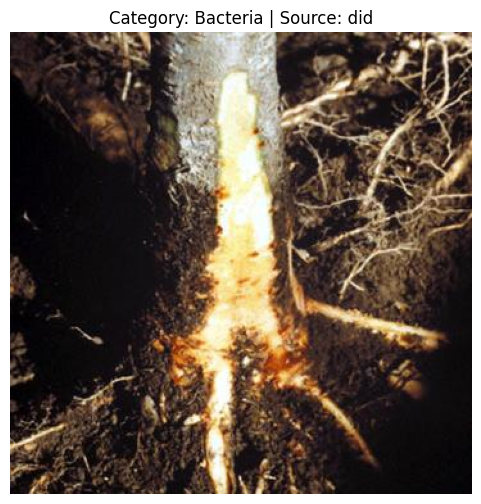


Question: What disease is affecting the plant?

Options:
  A. Northern Leaf Blight
  B. Pythium root rot
  C. Witches'-broom
  D. Purple stain
  E. Bacterial dieback of nectarine

Ground Truth: B - Bacterial dieback of nectarine
Prediction: B - B

Status: ✅ CORRECT

Sample 2


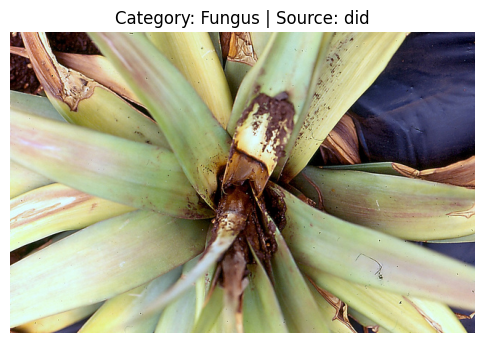


Question: What disease is affecting the plant?

Options:
  A. Cucumber mosaic
  B. Mealybug wilt
  C. Bacterial heart rot and fruit collapse
  D. Pink disease
  E. Phytophthora heart and root rot

Ground Truth: E - Phytophthora heart and root rot
Prediction: C - C

Status: ❌ INCORRECT

Sample 3


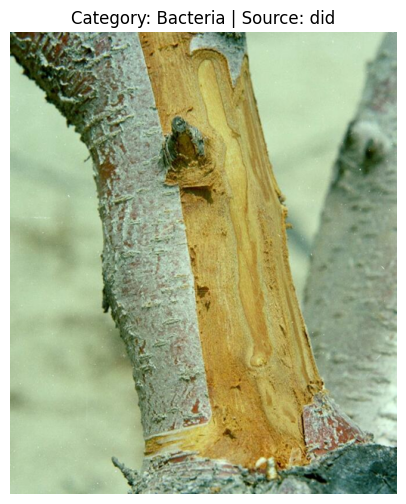


Question: What disease is affecting the plant?

Options:
  A. Rust
  B. Bacterial spot
  C. Bacterial canker
  D. Crown gall
  E. Scab

Ground Truth: B - Bacterial canker
Prediction: C - C

Status: ❌ INCORRECT

Sample 4


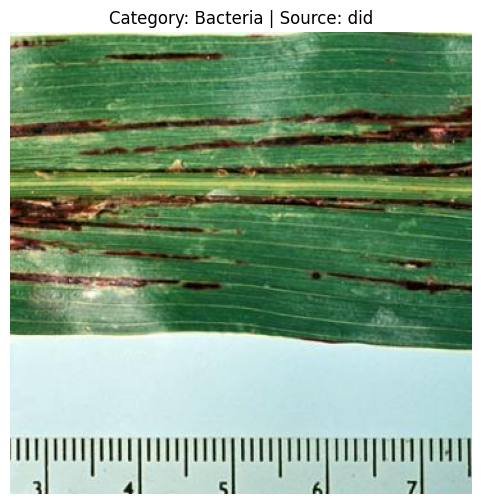


Question: What disease is affecting the plant?

Options:
  A. Ganoderma butt rot
  B. Slime flux
  C. Tungro
  D. Bacterial leaf streak
  E. Bacterial leaf stripe

Ground Truth: B - Bacterial leaf streak
Prediction: D - D

Status: ❌ INCORRECT

Sample 5


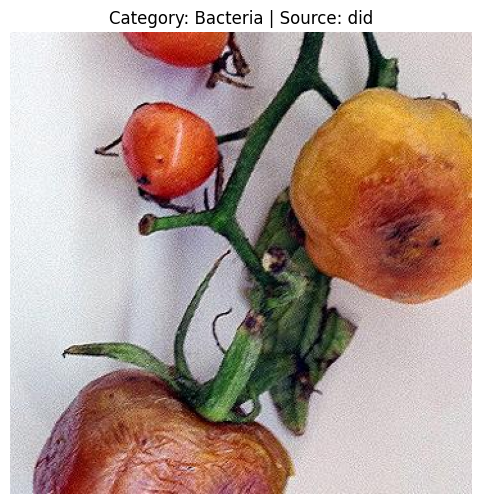


Question: What disease is affecting the plant?

Options:
  A. Fusarium wilt
  B. Bacterial fruit rot
  C. Black mold
  D. Gray mold
  E. Bacterial wilt

Ground Truth: B - Bacterial fruit rot
Prediction: B - B

Status: ✅ CORRECT

✅ Sample visualization complete!


In [19]:
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Show first 5 predictions
num_samples = min(5, len(all_results))

for idx in range(num_samples):
    result = all_results[idx]

    print("\n" + "="*80)
    print(f"Sample {idx + 1}")
    print("="*80)

    # Display image
    img = rows_iter[idx][CONFIG["image_column"]]
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Category: {result['category']} | Source: {result['source']}")
    plt.show()

    # Display question and options
    print(f"\nQuestion: {result['question']}")
    print("\nOptions:")
    for i, opt in enumerate(result['options']):
        print(f"  {LETTER[i]}. {opt}")

    # Display prediction vs ground truth
    correct = result['pred_letter'] == result['gold_letter']
    status = "✅ CORRECT" if correct else "❌ INCORRECT"

    print(f"\nGround Truth: {result['gold_letter']} - {result['gold_text']}")
    print(f"Prediction: {result['pred_letter']} - {result['pred_text']}")
    print(f"\nStatus: {status}")
    print("="*80)

print("\n✅ Sample visualization complete!")

## 9. Download Results (Optional)

Download the predictions and evaluation report to your local machine.

In [20]:
from google.colab import files

# Download predictions
print("Downloading predictions...")
files.download(pred_path)

# Download report
print("Downloading evaluation report...")
files.download(report_path)

print("✅ Files downloaded successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded successfully!
